In [1]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster
import xarray as xr
import gcsfs
import pandas as pd
from tqdm.notebook import tqdm
import os
import dask.bag as db


fs = gcsfs.GCSFileSystem(token='anon')  # public access

cluster = LocalCluster(n_workers=32, memory_limit='4GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 128.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39381,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45873,Total threads: 1
Dashboard: http://127.0.0.1:32875/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:38299,


In [2]:
all_days = pd.date_range('1940-01-01', freq='D', end='2024-12-31')

new_grid = xr.DataArray(dims=['latitude','longitude'], coords = dict(latitude=np.arange(0.,90,1.),
                                                          longitude=np.arange(0.,360.,1.)))
main_path_out = '/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily'
main_url_pressure = 'gcp-public-data-arco-era5/raw/date-variable-pressure_level'
main_url_single = 'gcp-public-data-arco-era5/raw/date-variable-single_level'



def download_u850_day(day):
    path_out_u850 = f"{main_path_out}/u850/u850_{day.strftime("%Y_%m_%d")}_era5_1deg_daily.nc"
    if os.path.exists(path_out_u850):
        return#print('File exists')
    try:
        url_u850 = f'{main_url_pressure}/{day.year}/{day.month:02.0f}/{day.day:02.0f}/u_component_of_wind/850.nc'
        with fs.open(url_u850) as f:
            with xr.open_dataset(f) as ds:
                ds_var = ds.u.sel(latitude=slice(90,0))
                mean_ds_new_grid = ds_var.mean('time').interp_like(new_grid)
                mean_ds_new_grid = mean_ds_new_grid.assign_coords(longitude=(((mean_ds_new_grid.longitude + 180) % 360) - 180))
                mean_ds_new_grid = mean_ds_new_grid.sortby('longitude')
                mean_ds_new_grid.assign_coords(time=day).to_netcdf(path_out_u850)
                del ds_var
                del mean_ds_new_grid
    except:
        print(f'Failed {day}')
    return


def download_slp_day(day):
    path_out_slp = f"{main_path_out}/slp/slp_{day.strftime("%Y_%m_%d")}_era5_1deg_daily.nc"
    if os.path.exists(path_out_slp):
        return#print('File exists')
    try:
        url_slp = f'{main_url_single}/{day.year}/{day.month:02.0f}/{day.day:02.0f}/mean_sea_level_pressure/surface.nc'
        with fs.open(url_slp) as f:
            with xr.open_dataset(f) as ds:
                ds_var = ds.msl.sel(latitude=slice(90,0))
                mean_ds_new_grid = ds_var.mean('time').interp_like(new_grid)
                mean_ds_new_grid = mean_ds_new_grid.assign_coords(longitude=(((mean_ds_new_grid.longitude + 180) % 360) - 180))
                mean_ds_new_grid = mean_ds_new_grid.sortby('longitude')
                mean_ds_new_grid.assign_coords(time=day).to_netcdf(path_out_slp)
                del ds_var
                del mean_ds_new_grid
    except:
        print(f'Failed {day}')
    return

def download_v850_day(day):
    path_out_v850 = f"{main_path_out}/v850/v850_{day.strftime("%Y_%m_%d")}_era5_1deg_daily.nc"
    if os.path.exists(path_out_v850):
        return#print('File exists')
    try:
        url_v850 = f'{main_url_pressure}/{day.year}/{day.month:02.0f}/{day.day:02.0f}/v_component_of_wind/850.nc'
        with fs.open(url_v850) as f:
            with xr.open_dataset(f) as ds:
                ds_var = ds.v.sel(latitude=slice(90,0))
                mean_ds_new_grid = ds_var.mean('time').interp_like(new_grid)
                mean_ds_new_grid = mean_ds_new_grid.assign_coords(longitude=(((mean_ds_new_grid.longitude + 180) % 360) - 180))
                mean_ds_new_grid = mean_ds_new_grid.sortby('longitude')
                mean_ds_new_grid.assign_coords(time=day).to_netcdf(path_out_v850)
                del ds_var
                del mean_ds_new_grid
    except:
        print(f'Failed {day}')
    return



In [ ]:
bag = db.from_sequence(all_days)
results = bag.map(download_u850_day).compute()

## Make yearly files

In [ ]:
# ds_slp = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/slp/yearly/*.nc',engine='h5netcdf')
# ds_u850 = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/yearly/*.nc',engine='h5netcdf')
# ds_v850 = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/v850/yearly/*.nc',engine='h5netcdf')

In [4]:
variable='slp'
year=1954
ds = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/{variable}/yearly/{variable}_{year}_era5_1deg_daily_NH.nc')

In [ ]:
ds.rename(year='time')
ds.close()

/tmp/ipykernel_2559732/2534252264.py:1: UserWarning: rename 'year' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds.rename(year='time')


<xarray.Dataset> Size: 95MB
Dimensions:    (time: 365, latitude: 90, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    time       (time) datetime64[ns] 3kB ...
Data variables:
    msl        (time, latitude, longitude) float64 95MB ...

In [ ]:
variable='slp'
year='1954'
ds = xr.open_mfdataset(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/{variable}/{variable}_{year}_*', combine='nested', concat_dim='year')
ds.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/{variable}/yearly/{variable}_{year}_era5_1deg_daily_NH.nc')

In [10]:
ds = xr.open_dataset("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr")
df = ds.data_normed.isnull().sum(['longitude','latitude']).to_series()
lines = df.where(df>0).dropna().reset_index().sort_values(['var_name','time'])
lines['year'] = lines.time.dt.year
lines = lines.groupby(['var_name','year']).time.count().reset_index()

for row, line in lines.groupby(['var_name','year']).time.count().reset_index().iterrows():
    variable=line.var_name
    year=line.year
    print(variable, year)
    ds = xr.open_mfdataset(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/{variable}/{variable}_{year}_*', combine='nested', concat_dim='time')
    ds.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/{variable}/yearly/{variable}_{year}_era5_1deg_daily_NH.nc')

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:43: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


slp 1954
slp 1974
slp 1990
slp 2004
slp 2010
slp 2017
slp 2024
u850 1947
u850 1958
u850 1964
u850 1989
u850 1990
v850 1949
v850 1950
v850 1951
v850 1953
v850 1954
v850 1966
v850 1968
v850 1969
v850 1978
v850 1988
v850 1989
v850 1995
v850 2001
v850 2004
v850 2008
v850 2009
v850 2013
v850 2014
v850 2016


In [22]:
path

'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/v850/v850_2016_09_04_era5_1deg_daily.nc'

In [ ]:

grid_regions = xr.open_dataarray('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/ERA5_rainfall_regions.nc')
grid_regions= grid_regions.rename('region_id').drop_vars('number').rename(lon='longitude', lat='latitude')
mask = (grid_regions==14)&(grid_regions.longitude>0)
new_grid = xr.DataArray(dims=['latitude','longitude'], coords=dict(longitude=np.arange(0,360,.25),
                                                                   latitude=np.arange(90,-90,-.25)))
mask = (mask*1).interp_like(new_grid, method='nearest')
mask = mask.where(mask==1, drop=True)

def get_rain(day):
    # path_out_v850 = f"{main_path_out}/v850/v850_{day.strftime("%Y_%m_%d")}_era5_1deg_daily.nc"
    try:
        url_pr = f'{main_url_single}/{day.year}/{day.month:02.0f}/{day.day:02.0f}/total_precipitation/surface.nc'
        with fs.open(url_pr) as f:
            with xr.open_dataset(f) as ds:
                ds_var = ds.tp.sel(latitude=slice(90,0))
                mean_pr_WN = ds_var.where(mask==1).weighted(np.cos(np.deg2rad(mask.latitude))).mean(['longitude','latitude'], keep_attrs=True)
                del ds_var
                return mean_pr_WN
    except:
        print(f'Failed {day}')
    return



In [ ]:
bag = db.from_sequence(all_days)
results_rain = bag.map(get_rain).compute()
rain = xr.concat(results_rain, dim='time')
r = (rain*1000).resample(time='D').sum().isel(expver=0, drop=True)
r = r.assign_attrs(units='mm/day', long_name='total_precipitation')
r.rename('tp').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')

<xarray.DataArray 'tp' (time: 24)> Size: 192B
array([1.84176576e-05, 9.18329467e-06, 2.26288002e-05, 3.70770965e-05,
       5.43446928e-05, 1.12639896e-04, 1.50250629e-04, 1.65281440e-04,
       1.29267034e-04, 1.19083283e-04, 1.03782467e-04, 1.28280834e-04,
       1.27494263e-04, 1.45604359e-04, 1.62909531e-04, 1.12405635e-04,
       9.61870688e-05, 1.06124421e-04, 1.30605480e-04, 1.60224330e-04,
       1.86353243e-04, 2.37273680e-04, 3.03886166e-04, 3.15976404e-04])
Coordinates:
  * time     (time) datetime64[ns] 192B 2022-02-19 ... 2022-02-19T23:00:00
Attributes:
    units:      m
    long_name:  Total precipitation

In [ ]:
# lines['year'] = lines.time.dt.year


,var_name,year,time
0,slp,1954,1
1,slp,1974,1
2,slp,1990,1
3,slp,2004,1
4,slp,2010,1
5,slp,2017,1
6,slp,2024,1
7,u850,1947,1
8,u850,1958,1
9,u850,1964,1


/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:43: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [9]:
download_slp_day(all_days[0])

<xarray.Dataset> Size: 199MB
Dimensions:    (time: 24, latitude: 721, longitude: 1440)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 192B 1940-01-01 ... 1940-01-01T23:00:00
Data variables:
    msl        (time, latitude, longitude) float64 199MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-08-30 16:48:45 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...


In [10]:
ds

NameError: name 'ds' is not defined

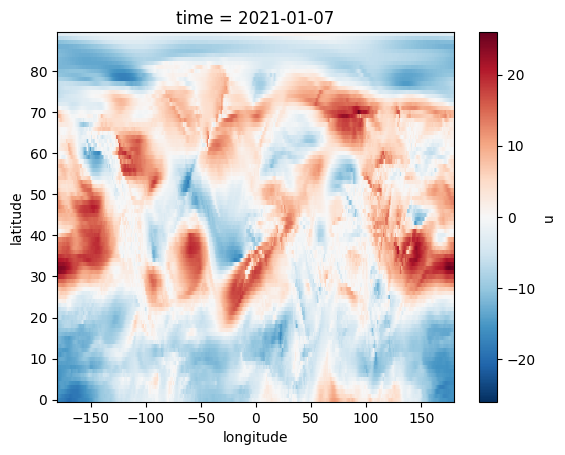

In [3]:
xr.open_dataset(f'{main_path_out}/u850/u850_2021_01_07_era5_1deg_daily.nc').u.plot()

AttributeError: 'QuadMesh' object has no attribute 'assign_coords'

15.96

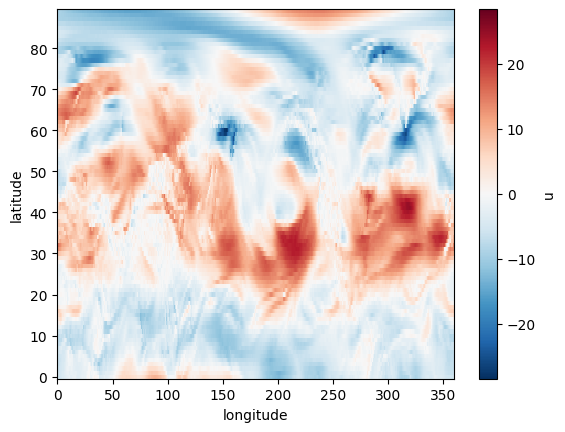

In [8]:
xr.open_dataset(path_out_u850).u.plot()

In [39]:
mean_ds.longitude

<xarray.DataArray 'longitude' (longitude: 1440)> Size: 6kB
array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02], shape=(1440,), dtype=float32)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    units:      degrees_east
    long_name:  longitude

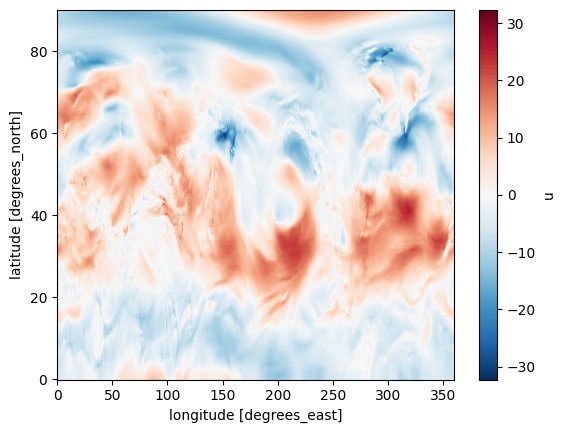

In [15]:
mean_ds.sel(latitude=slice(90,0)).plot()

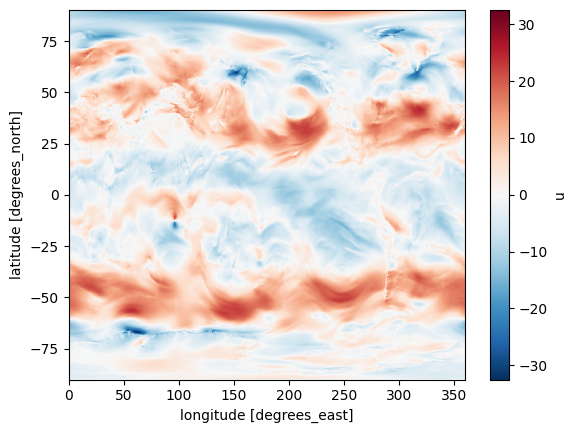

In [6]:
ds.mean('time').plot()

In [10]:
(ds.mean('time').nbytes/1e9)

0.00830592

In [3]:
xr.open_dataset('https://storage.googleapis.com/gcp-public-data-arco-era5/raw/date-variable-pressure_level/1940/01/01/u_component_of_wind/850.nc')

syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <?xml^ version='1.0' encoding='UTF-8'?><Error><Code>NoSuchKey</Code><Message>The specified key does not exist.</Message><Details>No such object: gcp-public-data-arco-era5/raw/date-variable-pressure_level/1940/01/01/u_component_of_wind/850.nc.dds</Details></Error>


OSError: [Errno -90] NetCDF: file not found: 'https://storage.googleapis.com/gcp-public-data-arco-era5/raw/date-variable-pressure_level/1940/01/01/u_component_of_wind/850.nc'

In [15]:
era5 = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr/',
    chunks=dict(time=8*1000, latitude=64, level=1),
    storage_options=dict(token='anon'),
)

# era5 = xr.open_zarr(
#     'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr',
#     chunks=dict(longitude=64, latitude=128, time=8*31, level=1),
#     storage_options=dict(token='anon'),
# )


/tmp/ipykernel_2301387/2783139829.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  era5 = xr.open_zarr(
/tmp/ipykernel_2301387/2783139829.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "level" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  era5 = xr.open_zarr(


In [16]:
era5

<xarray.Dataset> Size: 5TB
Dimensions:                                           (time: 92044,
                                                       longitude: 512,
                                                       latitude: 256, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 2kB ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 4kB ...
  * time                                              (time) datetime64[ns] 736kB ...
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 48GB dask.array<chunksize=(8000, 512, 64), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 48GB dask.array<chunksize=(8000, 512, 64), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 48GB dask.array<chunksize=(8000, 512, 64), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 48GB dask.array<chunksize=(8000, 512, 64), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 524kB dask.array<chunksize=(512, 64), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 524kB dask.array<chunksize=(512, 64), meta=np.ndarray>
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 524kB dask.array<chunksize=(512, 64), meta=np.ndarray>
    type_of_low_vegetation                            (longitude, latitude) float32 524kB dask.array<chunksize=(512, 64), meta=np.ndarray>
    u_component_of_wind                               (time, level, longitude, latitude) float32 627GB dask.array<chunksize=(8000, 1, 512, 64), meta=np.ndarray>
    v_component_of_wind                               (time, level, longitude, latitude) float32 627GB dask.array<chunksize=(8000, 1, 512, 64), meta=np.ndarray>
    vertical_velocity                                 (time, level, longitude, latitude) float32 627GB dask.array<chunksize=(8000, 1, 512, 64), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 627GB dask.array<chunksize=(8000, 1, 512, 64), meta=np.ndarray>

In [18]:
era5_features = era5[['mean_sea_level_pressure']].rename(mean_sea_level_pressure='slp')
era5_features['u850'] = era5['u_component_of_wind'].sel(level=850, drop=True).rename('u850')
era5_features['v850'] = era5['v_component_of_wind'].sel(level=850, drop=True).rename('v850')
era5_features['z500'] = era5['geopotential'].sel(level=500, drop=True).rename('z500')
era5_features['t850'] = era5['temperature'].sel(level=850, drop=True).rename('t850')


era5_features_array = era5_features.to_array('var_name').sel(latitude=slice(0,90)).coarsen(time=4).mean()
                                                            # longitude=slice(-120, 60),
                                                             
# era5_features_array_mean = era5_features_array.mean(['time'])
# anomaly = era5_features_array - era5_features_array_mean
# anomaly_std = anomaly.std(['longitude','latitude','time'])

# ds_out = xr.Dataset(dict(data_normed=anomaly/anomaly_std,
#                          mean_value = era5_features_array_mean,
#                          std_value = anomaly_std
#                          ),
#                     )
# ds_out = ds_out.transpose('time','var_name','latitude','longitude')#.load()
# ds_out['time'] = ds_out.time.dt.round('D')

# ds_east = ds_out.sel(longitude=slice(0,180))
# ds_west = ds_out.sel(longitude=slice(180.01,None))
# ds_west = ds_west.assign_coords(longitude=ds_west.longitude-360)
# ds_out = xr.concat([ds_west, ds_east], dim='longitude')

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/computation/rolling.py:1245: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  reduced = self.obj.variable.coarsen(


In [19]:
era5_features_array

<xarray.DataArray (var_name: 5, time: 23011, longitude: 512, latitude: 128)> Size: 30GB
dask.array<mean_agg-aggregate, shape=(5, 23011, 512, 128), dtype=float32, chunksize=(1, 2000, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 1kB 0.3516 1.055 1.758 ... 88.24 88.95 89.65
  * longitude  (longitude) float64 4kB 0.0 0.7031 1.406 ... 357.9 358.6 359.3
  * time       (time) datetime64[ns] 184kB 1959-01-01T09:00:00 ... 2021-12-31...
  * var_name   (var_name) object 40B 'slp' 'u850' 'v850' 'z500' 't850'

In [20]:
era5_features_array.isel(time=range(2000)).mean('time').plot(col='var_name')

2025-07-03 15:19:25,650 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-stack-getitem-3368853105c459f88eb55f63c6db6089', 1, 0, 0, 0))" coro=<Worker.execute() done, defined at /Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2025-07-03 15:19:25,651 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-stack-getitem-3368853105c459f88eb55f63c6db6089', 1, 0, 0, 1))" coro=<Worker.execute() done, defined at /Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2025-07-03 15:19:25,658 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-temperature-stack-getitem-3368853105c459f88eb55f63c6db6089', 4, 0, 0, 1))" coro=<Wor

KeyboardInterrupt: 

In [ ]:
from zarr.codecs import BloscCodec

compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
space_size = 'x'.join(list(np.array(ds_out.data_normed.shape[-2:]).astype(str)))
# ds_out = ds_out.chunk(time=5000)
ds_out.to_zarr(f"/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_{space_size}_.zarr", 
               encoding={"data_normed": {"compressors": (compressor,)},
                         "mean_value": {"compressors": (compressor,)},
                         "std_value": {"compressors": (compressor,)},
                         "longitude": {"compressors": (compressor,)},
                         "latitude": {"compressors": (compressor,)},
                         "time": {"compressors": (compressor,)},
                         "var_name": {"compressors": (compressor,)},
                         })


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
# era5_features = era5[['u_component_of_wind','v_component_of_wind']].sel(level=850, drop=True).rename(u_component_of_wind='u850', v_component_of_wind='v850')

era5_features = era5[['total_column_water_vapour']].rename(total_column_water_vapour='tcwv')
era5_features['u850'] = era5['u_component_of_wind'].sel(level=850, drop=True).rename('u850')
era5_features['v850'] = era5['v_component_of_wind'].sel(level=850, drop=True).rename('v850')
era5_features['z500'] = era5['geopotential'].sel(level=500, drop=True).rename('z500')
era5_features['t850'] = era5['temperature'].sel(level=850, drop=True).rename('t850')

era5_features['w850'] = era5['vertical_velocity'].sel(level=850, drop=True).rename('w850')
era5_features['z850'] = era5['geopotential'].sel(level=850, drop=True).rename('z850')
era5_features['t2m'] = era5['2m_temperature'].rename('t2m')
era5_features['slp'] = era5['mean_sea_level_pressure'].rename('slp')



era5_features = era5_features.assign_coords(longitude=(((era5_features.longitude + 180) % 360) - 180)).sortby('longitude')


In [4]:
R = 6.371e6 
u = era5_features['u850'].load()
v = era5_features['v850'].load()

lat = np.deg2rad(u['latitude'])
lon = np.deg2rad(u['longitude'])

# Compute grid spacing (assuming regular grid)
dlat = np.gradient(lat)
dlon = np.gradient(lon)

# Cosine of latitude
cos_lat = np.cos(lat)
sin_lat = np.sin(lat)

# Make 2D arrays for broadcasting
cos_lat_2d = xr.DataArray(cos_lat, coords=[u['latitude']], dims=['latitude'])

# ∂v / ∂λ
dv_dlon = v.differentiate('longitude') * (np.pi / 180)  # convert deg to rad

# ∂(u cos φ) / ∂φ
u_coslat = u * cos_lat_2d
ducoslat_dlat = u_coslat.differentiate('latitude') * (np.pi / 180)  # deg to rad

# Broadcast cos φ to 2D again if needed
cos_lat_2d_b = cos_lat_2d.broadcast_like(ducoslat_dlat)

# Final vorticity
vorticity = (dv_dlon - ducoslat_dlat) / (R * cos_lat_2d_b)
vorticity.name = 'vorticity'

era5_features['vorticity850'] = vorticity.chunk(dict( time=365*5))

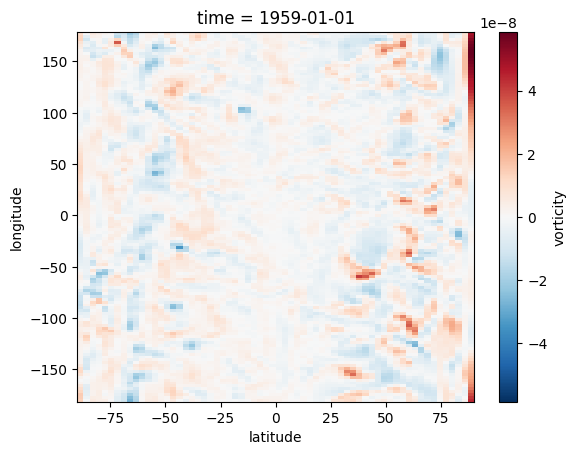

In [5]:
vorticity.isel(time=0).plot()

In [6]:

era5_features_array = era5_features.to_array('var_name').sel(latitude=slice(0,90)).coarsen(time=4).mean()
                                                            # longitude=slice(-120, 60),
                                                             
era5_features_array_mean = era5_features_array.mean(['time'])
anomaly = era5_features_array - era5_features_array_mean
anomaly_std = anomaly.std(['longitude','latitude','time'])

ds_out = xr.Dataset(dict(data_normed=anomaly/anomaly_std,
                         mean_value = era5_features_array_mean,
                         std_value = anomaly_std
                         ),
                    )
ds_out = ds_out.transpose('time','var_name','latitude','longitude')#.load()
ds_out['time'] = ds_out.time.dt.round('D')

In [7]:
from zarr.codecs import BloscCodec

compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
space_size = 'x'.join(list(np.array(ds_out.data_normed.shape[-2:]).astype(str)))
ds_out = ds_out.chunk(time=5000)
ds_out.to_zarr(f"/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_{space_size}_.zarr", 
               encoding={"data_normed": {"compressors": (compressor,)},
                         "mean_value": {"compressors": (compressor,)},
                         "std_value": {"compressors": (compressor,)},
                         "longitude": {"compressors": (compressor,)},
                         "latitude": {"compressors": (compressor,)},
                         "time": {"compressors": (compressor,)},
                         "var_name": {"compressors": (compressor,)},
                         })


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
2025-06-23 15:09:40,891 - distributed.dashboard.components.sch

In [2]:
ds = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_32x128.zarr")

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [3]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (var_name: 8, latitude: 32, longitude: 128, time: 23011)
Coordinates:
  * var_name     (var_name) object 64B 'tcwv' 'u850' 'v850' ... 't2m' 'slp'
  * longitude    (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * time         (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
  * latitude     (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
Data variables:
    mean_value   (var_name, latitude, longitude) float32 131kB dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 32B dask.array<chunksize=(1,), meta=np.ndarray>
    data_normed  (time, var_name, latitude, longitude) float32 3GB dask.array<chunksize=(1825, 1, 32, 128), meta=np.ndarray>

In [3]:
era5_rain = era5.total_precipitation_6hr.coarsen(time=4).sum()


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/computation/rolling.py:1245: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  reduced = self.obj.variable.coarsen(


In [16]:
era5_rain.mean('time').plot()

Task exception was never retrieved
future: <Task finished name='Task-4566646' coro=<Client._gather.<locals>.wait() done, defined at /Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/distributed/client.py:2197> exception=AllExit()>
Traceback (most recent call last):
  File "/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/distributed/client.py", line 2206, in wait
    raise AllExit()
distributed.client.AllExit
2025-06-13 17:17:56,766 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-total_precipitation_6hr-82bcc30d52051922fc454937ea4e4ef3', 3, 0, 0))" coro=<Worker.execute() done, defined at /Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2025-06-13 17:17:56,766 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_da

KeyboardInterrupt: 

2025-06-13 17:17:58,777 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-13 17:17:58,778 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-13 17:17:58,778 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-13 17:17:58,778 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-13 17:17:58,778 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-13 17:17:58,779 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Scienti

In [9]:
ds_out

<xarray.Dataset> Size: 3GB
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name     (var_name) object 64B 'tcwv' 'u850' 'v850' ... 't2m' 'slp'
  * time         (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 3GB dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 131kB dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 32B dask.array<chunksize=(1,), meta=np.ndarray>

In [44]:
ds_out

<xarray.Dataset>
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * var_name     (var_name) object 'tcwv' 'u850' 'v850' ... 'z500' 't2m' 'slp'
  * time         (time) datetime64[ns] 1959-01-01 1959-01-02 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 dask.array<chunksize=(1,), meta=np.ndarray>

FileExistsError: file:///Data/gfi/users/rogui7909/data/ERA5/dl_inputs_6H_32x128.zarr is not empty, but `mode` is set to 'w-'.Either remove the existing objects in storage,or set `mode` to a value that handles pre-existing objectsin storage, like `a` or `w`.

In [ ]:
ds_mask = xr.open_dataset('/Data/gfi/users/jodor4442/rainfall_regions/K39_ERA5land_lat_weighted_2d_direct.nc').interp_like(era5_features).tp#.sel(longitude=slice(-12,40), latitude=slice(30,90))
rain = era5['total_precipitation_6hr'].assign_coords(longitude=(((era5_features.longitude + 180) % 360) - 180)).sortby('longitude')
weights = xr.ones_like(ds_mask)*np.cos(np.deg2rad(ds_mask.latitude))
rain_TP = ((weights*rain).groupby(ds_mask).sum()/((weights).groupby(ds_mask).sum())).rename(tp='mask_id')
ds_out['rain_data'] = 
# ds_mask
# ds_mask.tp.plot()
# era5
# rain.groupby()

/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/xarray/core/dataset.py:4597: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  stacked_var = exp_var.stack(**{new_dim: dims})
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWar

<xarray.Dataset>
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * var_name     (var_name) object 'tcwv' 'u850' 'v850' ... 'z500' 't2m' 'slp'
  * time         (time) datetime64[ns] 1959-01-01 1959-01-02 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 dask.array<chunksize=(1,), meta=np.ndarray>

In [39]:
rain_TP

<xarray.DataArray (time: 92044, tp: 42)>
dask.array<truediv, shape=(92044, 42), dtype=float64, chunksize=(7300, 1), chunktype=numpy.ndarray>
Coordinates:
    number   int64 0
  * time     (time) datetime64[ns] 1959-01-01 ... 2021-12-31T18:00:00
  * tp       (tp) float64 1.0 3.0 4.0 5.0 5.438 6.0 ... 35.0 36.0 37.0 38.0 39.0

In [29]:
(weights).groupby(ds_mask)

/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


DataArrayGroupBy, grouped over 'tp'
42 groups with labels 1.0, 3.0, 4.0, ..., 37.0, 38.0, 39.0.

In [23]:
rain = era5['total_precipitation_6hr']
weights = xr.ones_like(ds_mask)*np.cos(np.deg2rad(ds_mask.latitude))
rain_TP = ((weights*rain).groupby(ds_mask).sum()/((weights).groupby(ds_mask).sum()))

ValueError: the group variable's length does not match the length of this variable along its dimensions

In [15]:
rain_TP

NameError: name 'rain_TP' is not defined

In [ ]:
ds_out.to_zarr('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_6H_32x128.zarr')

NameError: name 'ds_out' is not defined

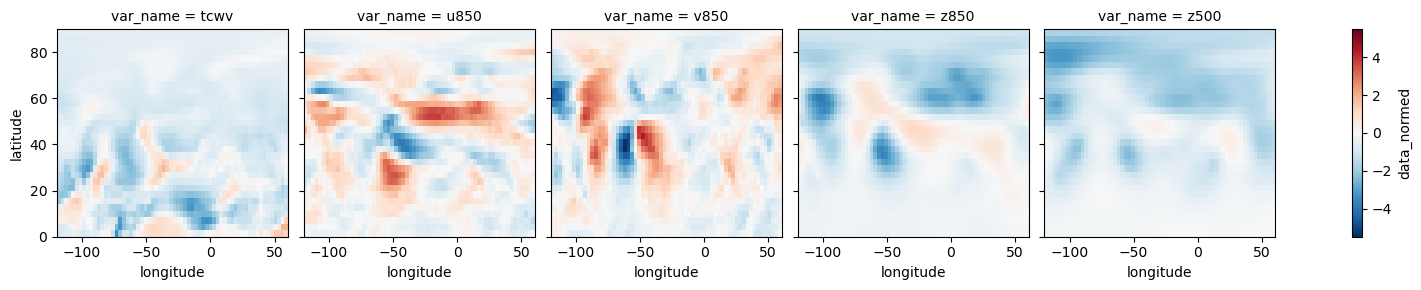

In [5]:
ds_out.data_normed.isel(time=0).plot(col='var_name')

In [7]:
values = ds_out.data_normed.values
np.save('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.npy', values)

In [ ]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc', chunks = dict(var_name=1))
# ds_in.close()
values = ds_in.data_normed.values


2025-02-25 16:10:41,690 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-data_normed-bd4351a1644c257196b07303e508282e', 0, 2, 0, 0))" coro=<Worker.execute() done, defined at /felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3606>> ended with CancelledError
2025-02-25 16:10:41,691 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-data_normed-bd4351a1644c257196b07303e508282e', 0, 1, 0, 0))" coro=<Worker.execute() done, defined at /felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3606>> ended with CancelledError
2025-02-25 16:10:41,691 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-data_normed-bd4351a1644c257196b07303e508282e', 0, 3, 0, 0))" coro=

KeyboardInterrupt: 

Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):


In [9]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc', chunks = dict(var_name=1)).data_normed
print('wo1')
variables = {str(ds_in.var_name.values[k]):k for k in range(ds_in.var_name.size)}
variables

wo1


{'tcwv': 0, 'u850': 1, 'v850': 2, 'z850': 3, 'z500': 4}

In [17]:
input_variable = [ 'u850']

ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc', chunks = dict(var_name=1)).data_normed
print('wo1')
variables = {str(ds_in.var_name.values[k]):k for k in range(ds_in.var_name.size)}
ds_in = ds_in.sel(var_name=input_variable)
input_indices = [variables[k] for k in input_variable]
data_in = np.load('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.npy',allow_pickle=True )#[:,input_indices]
print('wo2')

data_in

wo1
wo2


array(<bound method Mapping.values of <xarray.Dataset> Size: 945MB
Dimensions:       (latitude: 32, longitude: 32, var_name: 5, time: 23011)
Coordinates:
  * latitude      (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude     (longitude) float64 256B -47.81 -45.0 -42.19 ... 36.56 39.38
  * var_name      (var_name) <U4 80B 'tcwv' 'u850' 'v850' 'z850' 'z500'
  * time          (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
Data variables:
    data_normed   (time, var_name, latitude, longitude) float64 943MB dask.array<chunksize=(23011, 1, 32, 32), meta=np.ndarray>
    mean_value    (time, var_name) float64 920kB dask.array<chunksize=(23011, 1), meta=np.ndarray>
    std_value     (time, var_name) float64 920kB dask.array<chunksize=(23011, 1), meta=np.ndarray>
    mean_removed  (var_name) int64 40B dask.array<chunksize=(1,), meta=np.ndarray>>,
      dtype=object)

# compute curl

In [ ]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc')


# Constants
g = 9.81  # Gravity (m/s^2)
Omega = 7.292e-5  # Earth's rotation rate (s^-1)

def coriolis_parameter(latitude):
    """Compute Coriolis parameter f at given latitudes."""
    return 2 * Omega * np.sin(np.deg2rad(latitude))

def geostrophic_winds(geo_height, latitudeitude, longitude):
    """
    Compute geostrophic wind components (u_g, v_g) from geopotential height.

    Parameters:
    geo_height : xarray.DataArray
        Geopotential height field with dimensions (latitude, longitude).
    latitude : xarray.DataArray
        latitude values.
    longitude : xarray.DataArray
        longitudegitude values.

    Returns:
    u_g, v_g : xarray.DataArray
        Geostrophic wind components (m/s).
    """
    f = coriolis_parameter(latitude)  # Compute Coriolis parameter
    
    # Compute horizontal gradients using xarray's differentiation
    dZ_dy = geo_height.differentiate("latitude") / 111000  # Convert degrees to meters
    dZ_dx = geo_height.differentiate("longitude") / (111000 * np.cos(np.deg2rad(latitude)))  # Adjust for longitudegitude scaling
    
    # Compute geostrophic wind components
    u_g = - (g / f) * dZ_dy
    v_g = (g / f) * dZ_dx
    
    return u_g, v_g

# Example usage with a dataset
# geo_height = ds_in["z500"]  # Replace "Z" with the actual variable name
latitude = ds_in["latitude"]
longitude = ds_in["longitude"]

u850_g, v850_g = geostrophic_winds(ds_in.data_normed.sel(var_name="z850"), latitude, longitude)
u500_g, v500_g = geostrophic_winds(ds_in.data_normed.sel(var_name="z500"), latitude, longitude)
ds_in_add = xr.concat([u850_g.assign_coords(var_name='u850_g'),
                       v850_g.assign_coords(var_name='v850_g'),
                       u500_g.assign_coords(var_name='u500_g'),
                       v500_g.assign_coords(var_name='v500_g')], dim='var_name')

# Add to dataset if needed
# Save or analyze the output
ds_out = xr.merge([ds_in,ds_in_add.rename('data_normed')])
ds_out.var_name.encoding = {'dtype': '<U6'}
ds_out.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_geostroph.nc')

In [ ]:
ds = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_geostroph.nc')
ds_out = ds.transpose('time','var_name','latitude','longitude')
u850_ag = (ds_out.sel(var_name='u850')[['data_normed']] - ds_out.sel(var_name='u850_g')[['data_normed']]).assign_coords(var_name='u850_ag')
v850_ag = (ds_out.sel(var_name='v850')[['data_normed']] - ds_out.sel(var_name='v850_g')[['data_normed']]).assign_coords(var_name='v850_ag')
ds_out2 = xr.concat([ds_out, u850_ag, v850_ag], dim='var_name')
ds_out2.mean_removed.values = [1,0,0,0,0,0,0,0,1,0,0]
ds_out2.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_ageostroph.nc')

In [55]:
ds_out = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_geostroph.nc')
# ds_out.sel(var_name='u850_g')
ds_out.var_name

<xarray.DataArray 'var_name' (var_name: 9)> Size: 216B
array(['tcwv', 'u500_g', 'u850', 'u850_g', 'v500_g', 'v850', 'v850_g', 'z500',
       'z850'], dtype='<U6')
Coordinates:
  * var_name  (var_name) <U6 216B 'tcwv' 'u500_g' 'u850' ... 'z500' 'z850'

In [30]:
ds_out.data_normed.values.shape

(23011, 9, 32, 32)

In [18]:
data=  era5_features.u850.isel(time=0).load()

In [22]:
data.sel(longitude=slice(-50,42),latitude=slice(0,90))

<xarray.DataArray 'u850' (longitude: 32, latitude: 32)> Size: 4kB
array([[-9.3948917e+00, -8.0623636e+00, -7.0682917e+00, ...,
        -7.0592843e-02,  2.2264652e+00,  1.6002868e+00],
       [-8.9804630e+00, -8.4344177e+00, -6.7126689e+00, ...,
         3.0978599e-03,  2.3072870e+00,  1.6983421e+00],
       [-8.2354860e+00, -8.7053480e+00, -7.0348372e+00, ...,
         1.3868183e-01,  2.3848023e+00,  1.7905636e+00],
       ...,
       [-2.7196548e+00, -6.8852391e+00, -1.3337133e+00, ...,
        -2.2063532e+00, -6.8430883e-01,  4.5552680e-01],
       [-3.9394259e+00, -9.4559002e+00, -1.0458354e-01, ...,
        -2.6473794e+00, -2.3256190e-01,  3.9519259e-01],
       [-5.0830889e+00, -5.4648156e+00, -7.9500955e-01, ...,
        -2.6599379e+00,  2.4948396e-01,  3.4977823e-01]], dtype=float32)
Coordinates:
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    time       datetime64[ns] 8B 1959-01-01
  * longitude  (longitude) float64 256B -47.81 -45.0 -42.19 ... 36.56 39.38
Attributes:
    long_name:      U component of wind
    short_name:     u
    standard_name:  eastward_wind
    units:          m s**-1

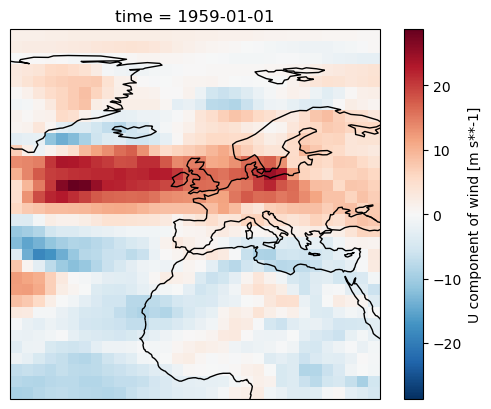

In [23]:
import cartopy.crs as ccrs
plot = data.sel(longitude=slice(-50,42),latitude=slice(0,90)).plot(x='longitude', y='latitude', subplot_kws=dict(projection=ccrs.PlateCarree()), transform =ccrs.PlateCarree())
plot.axes.coastlines()

In [ ]:
precip = era5['total_precipitation_6hr']*1000
precip_out = precip.sel(latitude=slice(0,90)).resample(time='D').sum(keep_attrs=True).rename('pr').to_dataset()
precip_out['mean_pr'] = precip_out.pr.weighted(np.cos(np.deg2rad(precip_out.latitude))).mean(['longitude','latitude','time'])
precip_out['std_pr'] = precip_out.pr.weighted(np.cos(np.deg2rad(precip_out.latitude))).std(['longitude','latitude','time'])

precip_out.assign_coords(longitude=(((precip_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/pr.nc')


In [32]:
tcwv = era5['total_column_water_vapour']
tcwv_out = tcwv.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('tcwv').to_dataset()
tcwv_out['mean_tcwv'] = tcwv_out.tcwv.weighted(np.cos(np.deg2rad(tcwv_out.latitude))).mean(['longitude','latitude','time'])
tcwv_out['std_tcwv'] = tcwv_out.tcwv.weighted(np.cos(np.deg2rad(tcwv_out.latitude))).std(['longitude','latitude','time'])

tcwv_out.assign_coords(longitude=(((tcwv_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/tcwv.nc')

In [29]:
uwind = era5['u_component_of_wind'].sel(level=850, drop=True).rename('u850')
uwind_out = uwind.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('u850').to_dataset()
uwind_out['mean_u850'] = uwind_out.u850.weighted(np.cos(np.deg2rad(uwind_out.latitude))).mean(['longitude','latitude','time'])
uwind_out['std_u850'] = uwind_out.u850.weighted(np.cos(np.deg2rad(uwind_out.latitude))).std(['longitude','latitude','time'])

uwind_out.assign_coords(longitude=(((uwind_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/u850.nc')

2025-02-13 12:46:12,249 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.66 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:46:14,449 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.56 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:46:15,983 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

In [30]:
vwind = era5['v_component_of_wind'].sel(level=850, drop=True).rename('v850')
vwind_out = vwind.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('v850').to_dataset()
vwind_out['mean_v850'] = vwind_out.v850.weighted(np.cos(np.deg2rad(vwind_out.latitude))).mean(['longitude','latitude','time'])
vwind_out['std_v850'] = vwind_out.v850.weighted(np.cos(np.deg2rad(vwind_out.latitude))).std(['longitude','latitude','time'])

vwind_out.assign_coords(longitude=(((vwind_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/v850.nc')

2025-02-13 12:55:05,337 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.63 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:55:08,092 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.63 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:55:18,144 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

In [22]:
z500 = era5['geopotential'].sel(level=850, drop=True).rename('z500')
z500_out = z500.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('z500').to_dataset()
z500_out['mean_z500'] = z500_out.z500.weighted(np.cos(np.deg2rad(z500_out.latitude))).mean(['longitude','latitude','time'])
z500_out['std_z500'] = z500_out.z500.weighted(np.cos(np.deg2rad(z500_out.latitude))).std(['longitude','latitude','time'])

z500_out.assign_coords(longitude=(((z500_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/z500.nc')

# make tensor

In [2]:

process_variables = dict(z500='standard',
                         u850='std_only',
                         v850='std_only',
                         tcwv='standard',
                         pr='standard'
                            )

In [3]:
variables = ['z500','u850','v850','tcwv','pr']
lon_extent = slice(-90,89.5)
lat_extent = slice(20,90)

print('loading data ...')
all_data_in = dict()
for variable in variables:
    with xr.open_dataset(f'/Data/gfi/users/rogui7909/data/ERA5/{variable}.nc', chunks = dict(longitude=50, latitude=50, time=365*10)) as ds:
        data_ = ds.sel(latitude=lat_extent, longitude=lon_extent)[variable]
        time = ds.time
        if process_variables[variable] == 'standard':
            data_ = (data_ - ds[f'mean_{variable}'].values)/ds[f'std_{variable}'].values
        elif process_variables[variable] == 'std_only':
            data_ = (data_)/ds[f'std_{variable}'].values
        all_data_in[variable]=data_
        print('   --> ',variable,'loaded')
data_in = xr.Dataset(all_data_in).to_array('var_name')
# data_in = data_in.transpose(1,0,2,3)
print('Input data ready')

# tensor_in = torch.Tensor(data_in).type(torch.float32)

loading data ...
   -->  z500 loaded
   -->  u850 loaded
   -->  v850 loaded
   -->  tcwv loaded
   -->  pr loaded
Input data ready


In [1]:
import numpy as np
import h5py



In [2]:
data = np.load( "/Data/gfi/users/rogui7909/data/ERA5/numpy_era5_in.npy")

In [ ]:
h5f = h5py.File('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', 'w')
h5f.create_dataset('z500', data=data[:,0])
h5f.create_dataset('u850', data=data[:,1])
h5f.create_dataset('v850', data=data[:,2])
h5f.create_dataset('tcwv', data=data[:,3])
h5f.create_dataset('pr', data=data[:,4])

h5f.close()

In [15]:
h5f = h5py.File('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', 'r')


In [ ]:
h5f['u850'][:]

In [ ]:
    variable_order = dict(z500=0,u850=1,v850=2,tcwv=3,pr=4)


<HDF5 dataset "pr": shape (23011, 100, 256), type "<f8">

In [ ]:
h5f.create_dataset('v850', data=data[:,0])
h5f.create_dataset('u850', data=data[:,0])
h5f.create_dataset('u850', data=data[:,0])
h5f.create_dataset('u850', data=data[:,0])


In [ ]:
import numpy as np
import h5py

a = np.random.random(size=(100,20))
h5f = h5py.File('data.h5', 'w')
h5f.create_dataset('dataset_1', data=a)
# <HDF5 dataset "dataset_1": shape (100, 20), type "<f8">

In [4]:
data_in = data_in.transpose('time','var_name','latitude','longitude').load()
# to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', engine="h5netcdf")

In [ ]:
data_dict = data_in.to_dict(data=True)

: 

: 

: 

: 

In [ ]:
import h5py

In [ ]:
with h5py.File('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', "w") as f:
    for var, values in data_dict["data_vars"].items():
        f.create_dataset(var, data=values["data"])

In [ ]:
data_in.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', engine="h5netcdf")

In [ ]:
data_numpy = data_in.transpose('time','var_name','latitude','longitude').values

# to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.nc')

In [ ]:
data_torch = torch.Tensor(data_numpy)

In [ ]:
np.save( "/Data/gfi/users/rogui7909/data/ERA5/numpy_era5_in.npy", data_numpy)

2025-02-14 12:13:55,081 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/utils_comm.py", line 441, in retry_operation
    return await retry(
           ^^^^^^^^^^

In [1]:
import torch

In [2]:
tensor_in = torch.load("/Data/gfi/users/rogui7909/data/ERA5/tensor_era5_in.pt", weights_only=True)

In [6]:
tensor_in.transpose(1,0,2,3)

TypeError: transpose() received an invalid combination of arguments - got (int, int, int, int), but expected one of:
 * (int dim0, int dim1)
 * (name dim0, name dim1)
